In [2]:
import importlib
import sys

# for math operations
import numpy as np

# for plotting
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

# for accelerated computing
import jax.numpy as jnp

In [3]:
import dubins_model
importlib.reload(dubins_model)
from dubins_model import Dubins3D

dubins = Dubins3D()

100%|##########|  2.8000/2.799999952316284 [00:00<00:00, 12.03sim_s/s]
/tmp/ipykernel_1211370/2885990704.py:31: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(x, y, value_func.val_grid[:, :, 0].T, levels=[0], colors='black', linewidths=1.5, linestyles='dashed', label='Zero level set')
/tmp/ipykernel_1211370/2885990704.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


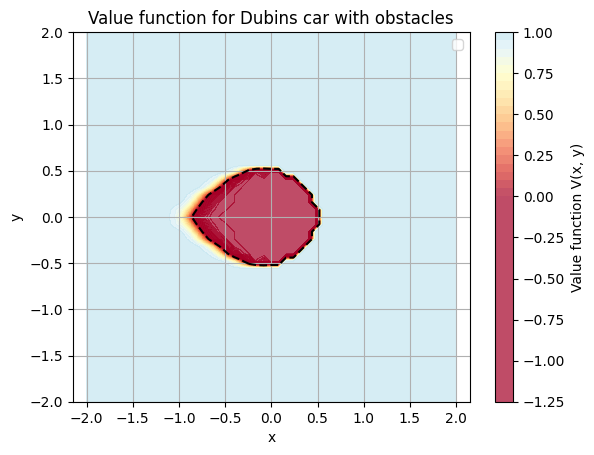

In [97]:
sys.path.append('./value_functions')
# import hj_value_function
# importlib.reload(hj_value_function)
from hj_value_function import HJValueFunction
from matplotlib import colors

value_func = HJValueFunction(dubins, 
                             grid_min=np.array([-2.0, -2.0, 0]),
                             grid_max=np.array([2.0, 2.0, 2 * np.pi]),
                             num_cells=np.array([51, 51, 51]))

# Define failure set
x_c, y_c, radius = 0.0, -1.2, 0.5
obstacle1 = jnp.linalg.norm(np.array([0.0, 0.0]) - value_func.grid.states[..., :2], axis=-1) - radius
# obstacle2 = jnp.linalg.norm(np.array([x_c, y_c]) - value_func.grid.states[..., :2] , axis=-1) - radius
# failure_lx = jnp.minimum(obstacle1, obstacle2)
# failure_lx = obstacle1

# if obstacle1 > 0, failure_lx = 1, else -1
failure_lx = jnp.where(obstacle1 > 0, 1.0, -1.0)

value_func.compute_V(failure_lx)

# Extract x and y grid for contour plotting
x = value_func.grid.states[..., 0][:, 0, 0]
y = value_func.grid.states[..., 1][0, :, 0]

# Create a custom colormap based on RdYlBu, but set 0 to white

# also plot the zero level set
plt.contour(x, y, value_func.val_grid[:, :, 0].T, levels=[0], colors='black', linewidths=1.5, linestyles='dashed', label='Zero level set')
plt.contourf(x, y, value_func.val_grid[:, :, 0].T, levels=50, cmap='RdYlBu', alpha=0.7)
plt.colorbar(label='Value function V(x, y)')
plt.legend()
plt.axis('equal')
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.grid()
plt.clim(0, 1.5)  # Adjust color limits for better visibility
plt.title('Value function for Dubins car with obstacles')
plt.xlabel('x')
plt.ylabel('y')
plt.show()



In [188]:
import torch

x_vals = np.linspace(-2, 2, 51)
y_vals = np.linspace(-2, 2, 51)
theta_vals = np.linspace(0, 2*np.pi, 51)
grid_points = np.array(np.meshgrid(x_vals, y_vals, theta_vals, indexing='ij')).reshape(3, -1).T

def reward_fn(states):
    d = np.linalg.norm(states[:, :2], axis=1)
    return np.where(d > radius, -1.0, 0.0)

def dynamics_step(state, action, dt=0.1):
    state_tensor = torch.tensor(state[None], dtype=torch.float32)
    action_tensor = torch.tensor(action[None], dtype=torch.float32)
    next_state = dubins.discrete_rk4(state_tensor, action_tensor, dt)
    return next_state[0].detach().numpy()

from scipy.interpolate import RegularGridInterpolator

def get_value_function_interpolator(V):
    return RegularGridInterpolator((x_vals, y_vals, theta_vals), V.reshape(51,51,51), bounds_error=False, fill_value=0.0)

V = np.zeros(len(grid_points))
gamma = 0.99
dt = 0.1
# actions = np.array([[-1.0], [0.0], [1.0]])
actions = np.linspace(-1.0, 1.0, 10).reshape(-1, 1)  # 10 actions from -1 to 1, reshaped to
num_states = grid_points.shape[0]
num_actions = actions.shape[0]

states = torch.tensor(grid_points, dtype=torch.float32)  # (S, 3)
rewards = reward_fn(grid_points)  # (S,)

goal_mask = np.linalg.norm(grid_points[:, :2], axis=1) <= radius  # (N,) boolean


for iteration in range(500):
    print(f"Iteration {iteration}")

    # Expand state-action pairs
    states_batch = states.repeat_interleave(num_actions, dim=0)  # (S*A, 3)
    actions_batch = torch.tensor(np.tile(actions, (num_states, 1)), dtype=torch.float32)  # (S*A, 1)

    # Batch dynamics
    next_states = dubins.discrete_rk4(states_batch, actions_batch, dt).detach().numpy()  # (S*A, 3)
    next_states[:, 2] = np.mod(next_states[:, 2], 2 * np.pi)

    # Interpolate value
    interp = get_value_function_interpolator(V)
    v_next = interp(next_states).reshape(num_states, num_actions)  # (S, A)

    # Bellman update
    total_return = rewards[:, None] + gamma * v_next  # (S, A)
    V_new = (np.max(total_return, axis=1))  # (S,)
    # V_new = np.maximum(rewards, np.max(total_return, axis=1))

    V_new[goal_mask] = 0.0

    print(f"Max value change: {np.max(np.abs(V_new - V))}")
    if np.max(np.abs(V_new - V)) < 1e-4:
        break
    V = V_new


Iteration 0
Max value change: 1.0
Iteration 1
Max value change: 0.99
Iteration 2
Max value change: 0.9801000000000004
Iteration 3
Max value change: 0.9702990000000002
Iteration 4
Max value change: 0.960596010000001
Iteration 5
Max value change: 0.9509900499000006
Iteration 6
Max value change: 0.9414801494010012
Iteration 7
Max value change: 0.9320653479069909
Iteration 8
Max value change: 0.9227446944279221
Iteration 9
Max value change: 0.913517247483643
Iteration 10
Max value change: 0.9043820750088063
Iteration 11
Max value change: 0.8953382542587178
Iteration 12
Max value change: 0.8863848717161318
Iteration 13
Max value change: 0.8775210229989696
Iteration 14
Max value change: 0.8687458127689798
Iteration 15
Max value change: 0.860058354641291
Iteration 16
Max value change: 0.8514577710948767
Iteration 17
Max value change: 0.8429431933839275
Iteration 18
Max value change: 0.8345137614500864
Iteration 19
Max value change: 0.8261683936481177
Iteration 20
Max value change: 0.817892221

In [190]:
V_out = -V.reshape(51, 51, 51)

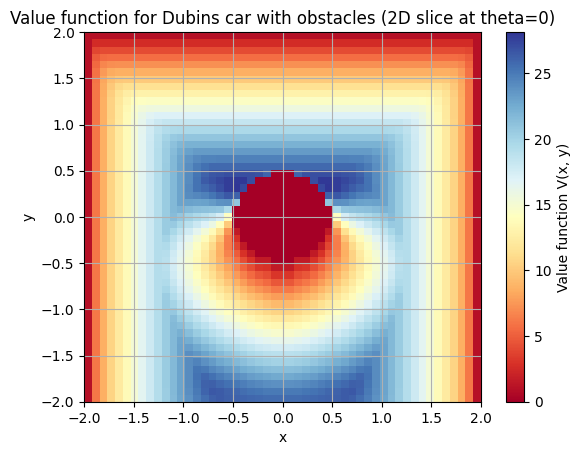

In [191]:
# plot a slice at theta = 0
V_2d = V_out.reshape(51, 51, 51)[:, :, 0]  # take the first slice at theta = 0
plt.imshow(V_2d, extent=(-2, 2, -2, 2), origin='lower', cmap='RdYlBu', aspect='auto')
plt.colorbar(label='Value function V(x, y)')
plt.title('Value function for Dubins car with obstacles (2D slice at theta=0)')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.grid()
plt.show()

In [192]:
x_vals = np.linspace(-2, 2, 51)
y_vals = np.linspace(-2, 2, 51)
theta_vals = np.linspace(0, 2*np.pi, 51)
grid_points = np.array(np.meshgrid(x_vals, y_vals, theta_vals, indexing='ij')).reshape(3, -1).T

def reward_fn(states):
    d = np.linalg.norm(states[:, :2], axis=1)
    # return np.where(d > radius, -1.0, 0.0)
    return np.where(d > radius, 0, 1)

def dynamics_step(state, action, dt=0.1):
    state_tensor = torch.tensor(state[None], dtype=torch.float32)
    action_tensor = torch.tensor(action[None], dtype=torch.float32)
    next_state = dubins.discrete_rk4(state_tensor, action_tensor, dt)
    return next_state[0].detach().numpy()

from scipy.interpolate import RegularGridInterpolator

def get_value_function_interpolator(V):
    return RegularGridInterpolator((x_vals, y_vals, theta_vals), V.reshape(51,51,51), bounds_error=False, fill_value=0.0)

V = np.zeros(len(grid_points))
gamma = 0.99
dt = 0.1
# actions = np.array([[-1.0], [0.0], [1.0]])
actions = np.linspace(-1.0, 1.0, 10).reshape(-1, 1)  # 10 actions from -1 to 1, reshaped to
num_states = grid_points.shape[0]
num_actions = actions.shape[0]

states = torch.tensor(grid_points, dtype=torch.float32)  # (S, 3)
rewards = reward_fn(grid_points)  # (S,)

goal_mask = np.linalg.norm(grid_points[:, :2], axis=1) >= radius  # (N,) boolean


for iteration in range(500):
    print(f"Iteration {iteration}")

    # Expand state-action pairs
    states_batch = states.repeat_interleave(num_actions, dim=0)  # (S*A, 3)
    actions_batch = torch.tensor(np.tile(actions, (num_states, 1)), dtype=torch.float32)  # (S*A, 1)

    # Batch dynamics
    next_states = dubins.discrete_rk4(states_batch, actions_batch, dt).detach().numpy()  # (S*A, 3)
    next_states[:, 2] = np.mod(next_states[:, 2], 2 * np.pi)

    # Interpolate value
    interp = get_value_function_interpolator(V)
    v_next = interp(next_states).reshape(num_states, num_actions)  # (S, A)

    # Bellman update
    total_return = rewards[:, None] + gamma * v_next  # (S, A)
    V_new = (np.max(total_return, axis=1))  # (S,)
    # V_new = np.maximum(rewards, np.max(total_return, axis=1))

    V_new[goal_mask] = 0.0

    print(f"Max value change: {np.max(np.abs(V_new - V))}")
    if np.max(np.abs(V_new - V)) < 1e-4:
        break
    V = V_new

Iteration 0
Max value change: 1.0
Iteration 1
Max value change: 0.9900000000000004
Iteration 2
Max value change: 0.9801000000000009
Iteration 3
Max value change: 0.9702990000000011
Iteration 4
Max value change: 0.9605960100000024
Iteration 5
Max value change: 0.9509900499000032
Iteration 6
Max value change: 0.941480149401003
Iteration 7
Max value change: 0.9320653479069936
Iteration 8
Max value change: 0.922744694427923
Iteration 9
Max value change: 0.9135172474836448
Iteration 10
Max value change: 0.9043820750088045
Iteration 11
Max value change: 0.8953382111747867
Iteration 12
Max value change: 0.8863847682707533
Iteration 13
Max value change: 0.8760400550302467
Iteration 14
Max value change: 0.8605390873738248
Iteration 15
Max value change: 0.8358400454198698
Iteration 16
Max value change: 0.7991486934214489
Iteration 17
Max value change: 0.7505835079836132
Iteration 18
Max value change: 0.6918593383831144
Iteration 19
Max value change: 0.626812476485
Iteration 20
Max value change: 

In [195]:
V_in = -V.reshape(51, 51, 51)

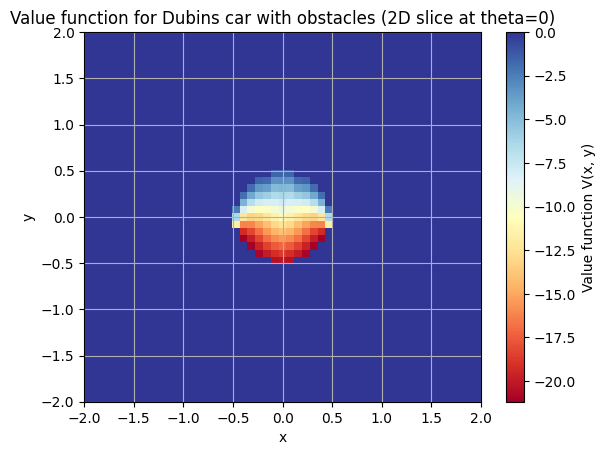

In [196]:
# plot a slice at theta = 0
V_2d = V_in.reshape(51, 51, 51)[:, :, 0]  # take the first slice at theta = 0
plt.imshow(V_2d, extent=(-2, 2, -2, 2), origin='lower', cmap='RdYlBu', aspect='auto')
plt.colorbar(label='Value function V(x, y)')
plt.title('Value function for Dubins car with obstacles (2D slice at theta=0)')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.grid()
plt.show()

In [197]:
V_tot = V_out + V_in

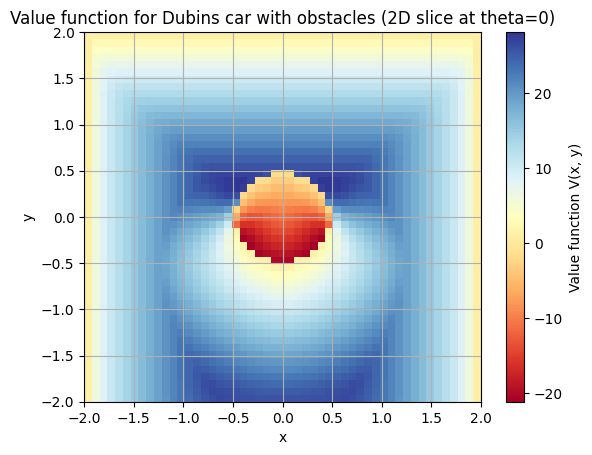

In [198]:
V_2d = (V_tot)[:, :, 0]  # take the first slice at theta = 0
plt.imshow(V_2d, extent=(-2, 2, -2, 2), origin='lower', cmap='RdYlBu', aspect='auto')
plt.colorbar(label='Value function V(x, y)')
plt.title('Value function for Dubins car with obstacles (2D slice at theta=0)')
plt.xlabel('x')
plt.ylabel('y')
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.grid()
plt.show()

100%|##########|  2.8000/2.799999952316284 [00:00<00:00, 12.19sim_s/s]
/tmp/ipykernel_1211370/3563926613.py:28: UserWarning: The following kwargs were not used by contour: 'label'
  plt.contour(x, y, value_func.val_grid[:, :, 0].T, levels=[0], colors='black', linewidths=1.5, linestyles='dashed', label='Zero level set')
/tmp/ipykernel_1211370/3563926613.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


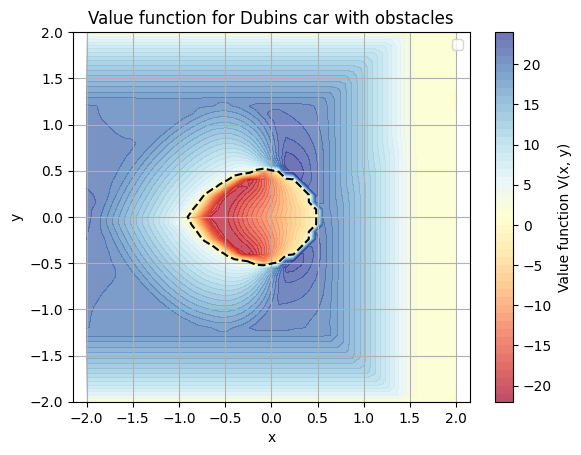

In [200]:
value_func = HJValueFunction(dubins, 
                             grid_min=np.array([-2.0, -2.0, 0]),
                             grid_max=np.array([2.0, 2.0, 2 * np.pi]),
                             num_cells=np.array([51, 51, 51]))

# Define failure set
x_c, y_c, radius = 0.0, -1.2, 0.5
# obstacle1 = jnp.linalg.norm(np.array([0.0, 0.0]) - value_func.grid.states[..., :2], axis=-1) - radius
# obstacle2 = jnp.linalg.norm(np.array([x_c, y_c]) - value_func.grid.states[..., :2] , axis=-1) - radius
# failure_lx = jnp.minimum(obstacle1, obstacle2)
# failure_lx = obstacle1

# if obstacle1 > 0, failure_lx = 1, else -1
# failure_lx = jnp.where(obstacle1 > 0, 1.0, -1.0)

# use the V as my failure set
failure_lx = V_tot

value_func.compute_V(failure_lx)

# Extract x and y grid for contour plotting
x = value_func.grid.states[..., 0][:, 0, 0]
y = value_func.grid.states[..., 1][0, :, 0]

# Create a custom colormap based on RdYlBu, but set 0 to white

# also plot the zero level set
plt.contour(x, y, value_func.val_grid[:, :, 0].T, levels=[0], colors='black', linewidths=1.5, linestyles='dashed', label='Zero level set')
plt.contourf(x, y, value_func.val_grid[:, :, 0].T, levels=50, cmap='RdYlBu', alpha=0.7)

# plot slice at theta = 0
# plt.imshow(value_func.val_grid[:, :, 0].T, extent=(-2, 2, -2, 2), origin='lower', cmap='RdYlBu', aspect='auto')

plt.colorbar(label='Value function V(x, y)')
plt.legend()
plt.axis('equal')
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.grid()
plt.title('Value function for Dubins car with obstacles')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

